In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import copy
from tqdm import tqdm

# --- Configuration ---
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH_SIZE = 128
LR = 0.01  # Lower LR for deep networks to prevent immediate NaN
EPOCHS = 5 # Reduced for demonstration speed (increase to 20 for full paper results)
SUBSET_SIZE = 2000 # Train on subset for rapid prototyping (set to None for full MNIST)

print(f"Running on device: {DEVICE}")

Running on device: cpu


In [3]:
class DeepMLP(nn.Module):
    """
    The 'Unhealthy' Deep Network (50 Layers).
    Used for Study 1 to demonstrate Collapse -> Sharpness correlation.
    """
    def __init__(self, depth=50, hidden=64, num_classes=10):
        super().__init__()
        layers = [nn.Flatten(), nn.Linear(28*28, hidden), nn.ReLU()]
        
        # Add intermediate layers
        for _ in range(depth - 2):
            layers.append(nn.Linear(hidden, hidden))
            layers.append(nn.ReLU())
            
        # Final classifier
        layers.append(nn.Linear(hidden, num_classes))
        self.net = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.net(x)

class ShallowCNN(nn.Module):
    """
    Control model for Study 2.
    Standard classifier width (128).
    """
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten()
        )
        self.classifier = nn.Sequential(
            nn.Linear(7*7*32, 128), # Standard Width
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        x = self.conv(x)
        return self.classifier(x)

class WideClassifierCNN(nn.Module):
    """
    Intervention model for Study 2.
    Widened classifier (1024) to test bottleneck hypothesis.
    """
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten()
        )
        self.classifier = nn.Sequential(
            nn.Linear(7*7*32, 1024), # Widened!
            nn.ReLU(),
            nn.Linear(1024, num_classes)
        )
    def forward(self, x):
        x = self.conv(x)
        return self.classifier(x)

In [5]:
def compute_layerwise_hessian_eig(model, data_loader, criterion, max_iters=20):
    """
    Computes the top Hessian Eigenvalue (sharpness) for each layer independently.
    Uses Power Iteration.
    """
    model.eval()
    layer_eigs = {}
    
    # Get a single batch for Hessian estimation (approximate but standard)
    xb, yb = next(iter(data_loader))
    xb, yb = xb.to(DEVICE), yb.to(DEVICE)
    
    print(f"Computing Hessian Eigenvalues for {model.__class__.__name__}...")
    
    for name, layer in tqdm(model.named_modules(), leave=False):
        # We only care about layers with weights (Linear, Conv2d)
        if isinstance(layer, (nn.Linear, nn.Conv2d)):
            params = list(layer.parameters())
            if len(params) == 0: continue
            
            # --- Power Iteration ---
            # 1. Random vector v
            v = [torch.randn_like(p) for p in params]
            # Normalize v
            norm_v = torch.sqrt(sum((vi**2).sum() for vi in v))
            v = [vi / norm_v for vi in v]
            
            for _ in range(max_iters):
                # Gradient of Loss w.r.t params
                model.zero_grad()
                output = model(xb)
                loss = criterion(output, yb)
                grads = torch.autograd.grad(loss, params, create_graph=True)
                
                # Gradient of (grads * v) w.r.t params -> Hessian * v
                grad_v_prod = sum((gi * vi).sum() for gi, vi in zip(grads, v))
                Hv = torch.autograd.grad(grad_v_prod, params, retain_graph=True)
                
                # Normalize new v
                norm_v = torch.sqrt(sum((hvi**2).sum() for hvi in Hv))
                v = [hvi / (norm_v + 1e-6) for hvi in Hv]
            
            # The norm is the eigenvalue estimate
            layer_eigs[name] = norm_v.item()
            
    return layer_eigs

def compute_layerwise_volume(model, data_loader):
    """
    Computes the Log-Volume (Log-Determinant of Covariance) of representations.
    Metric for 'Representational Collapse'.
    """
    model.eval()
    activations = {}
    hooks = []

    # Hook function to capture output of each layer
    def get_activation(name):
        def hook(model, input, output):
            # Flatten output: (Batch, Features)
            act = output.detach().flatten(1)
            if name not in activations:
                activations[name] = act
            else:
                activations[name] = torch.cat((activations[name], act), dim=0)
        return hook

    # Register hooks
    for name, layer in model.named_modules():
        if isinstance(layer, (nn.Linear, nn.Conv2d)):
            hooks.append(layer.register_forward_hook(get_activation(name)))

    # Pass data
    with torch.no_grad():
        # Limit to 500 samples to prevent OOM during SVD
        count = 0
        for xb, _ in data_loader:
            xb = xb.to(DEVICE)
            model(xb)
            count += xb.size(0)
            if count >= 500: break
    
    # Remove hooks
    for h in hooks: h.remove()
    
    # Compute Log-Volume
    layer_volumes = {}
    print(f"Computing Log-Volumes for {model.__class__.__name__}...")
    
    for name, acts in activations.items():
        # Center the data
        acts = acts - acts.mean(dim=0, keepdim=True)
        # Covariance Matrix (N x N) or (D x D), whichever is smaller for efficiency
        # SVD of X gives sqrt(eigenvalues of Cov)
        try:
            _, S, _ = torch.svd(acts)
            # Log Volume = Sum(Log(SingularValues^2)) approx LogDet
            # We use sum of log singular values as a robust proxy
            log_vol = torch.sum(torch.log(S + 1e-6)).item()
            layer_volumes[name] = log_vol
        except:
            layer_volumes[name] = float('nan')
            
    return layer_volumes

In [7]:
def get_dataloaders():
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
    train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST('./data', train=False, transform=transform)
    
    if SUBSET_SIZE:
        indices = torch.randperm(len(train_dataset))[:SUBSET_SIZE]
        train_dataset = Subset(train_dataset, indices)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    return train_loader, test_loader

def train_network(model, train_loader, epochs=EPOCHS):
    model = model.to(DEVICE)
    optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9)
    criterion = nn.CrossEntropyLoss()
    
    model.train()
    for ep in range(epochs):
        total_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {ep+1}: Loss {total_loss / len(train_loader):.4f}")
    return model, criterion

In [9]:
# 1. Setup
train_loader, test_loader = get_dataloaders()
deep_model = DeepMLP(depth=50, hidden=64).to(DEVICE)

# 2. Train
print("\n--- Training DeepMLP (50 Layers) ---")
deep_model, criterion = train_network(deep_model, train_loader)

# 3. Analyze
hessian_eigs = compute_layerwise_hessian_eig(deep_model, train_loader, criterion)
log_volumes = compute_layerwise_volume(deep_model, train_loader)

# 4. Correlation Analysis
layers = []
vols = []
eigs = []

# Align data by layer name
for name in hessian_eigs.keys():
    if name in log_volumes:
        layers.append(name)
        vols.append(log_volumes[name])
        eigs.append(hessian_eigs[name])

# Convert to arrays
vols = np.array(vols)
eigs = np.array(eigs)

# Remove NaNs if any
mask = ~np.isnan(vols)
vols = vols[mask]
eigs = eigs[mask]

# Compute Pearson Correlation
r, p_val = stats.pearsonr(vols, eigs)

100%|██████████████████████████████████████| 9.91M/9.91M [00:01<00:00, 8.46MB/s]
100%|███████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 364kB/s]
100%|██████████████████████████████████████| 1.65M/1.65M [00:00<00:00, 2.74MB/s]
100%|██████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 4.85MB/s]



--- Training DeepMLP (50 Layers) ---
Epoch 1: Loss 2.3060
Epoch 2: Loss 2.3039
Epoch 3: Loss 2.3019
Epoch 4: Loss 2.3011
Epoch 5: Loss 2.3004
Computing Hessian Eigenvalues for DeepMLP...


Computing Log-Volumes for DeepMLP...


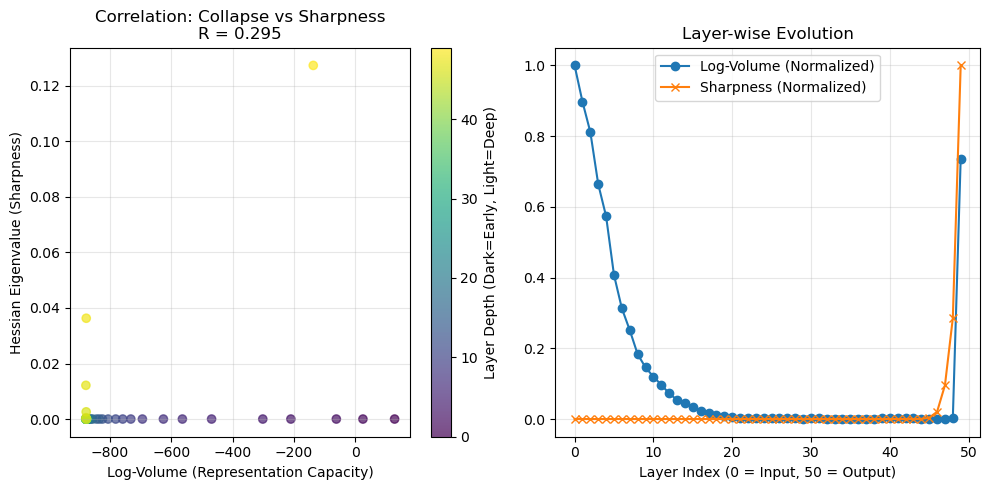

Study 1 Result: Pearson Correlation r=0.295. (Negative r supports hypothesis)


In [11]:
# 5. Plotting Study 1
plt.figure(figsize=(10, 5))

# Plot A: Scatter
plt.subplot(1, 2, 1)
plt.scatter(vols, eigs, c=np.arange(len(vols)), cmap='viridis', alpha=0.7)
plt.xlabel("Log-Volume (Representation Capacity)")
plt.ylabel("Hessian Eigenvalue (Sharpness)")
plt.title(f"Correlation: Collapse vs Sharpness\nR = {r:.3f}")
plt.colorbar(label='Layer Depth (Dark=Early, Light=Deep)')
plt.grid(True, alpha=0.3)

# Plot B: Layer-wise Trends
plt.subplot(1, 2, 2)
norm_vols = (vols - vols.min()) / (vols.max() - vols.min()) # Normalize for visual comparison
norm_eigs = (eigs - eigs.min()) / (eigs.max() - eigs.min())

plt.plot(norm_vols, label="Log-Volume (Normalized)", marker='o')
plt.plot(norm_eigs, label="Sharpness (Normalized)", marker='x')
plt.xlabel("Layer Index (0 = Input, 50 = Output)")
plt.title("Layer-wise Evolution")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Study 1 Result: Pearson Correlation r={r:.3f}. (Negative r supports hypothesis)")


--- Study 2: Bottleneck Ablation ---
Training Control: ShallowCNN...
Epoch 1: Loss 2.2401
Epoch 2: Loss 1.5504
Epoch 3: Loss 0.7653
Training Intervention: WideClassifierCNN...
Epoch 1: Loss 2.1951
Epoch 2: Loss 1.2344
Epoch 3: Loss 0.6085
Computing Hessian Eigenvalues for ShallowCNN...


Computing Hessian Eigenvalues for WideClassifierCNN...


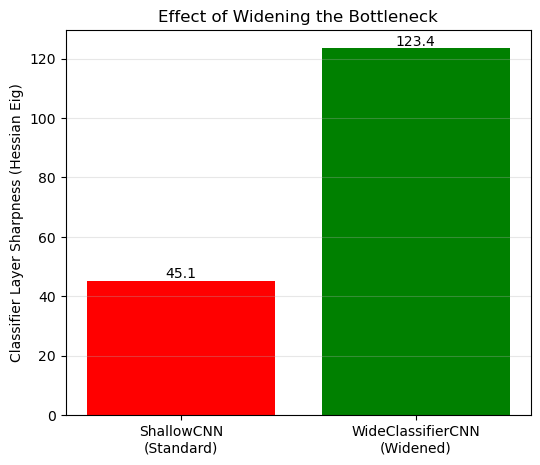

Study 2 Result: Control Sharpness: 45.12 vs. Wide Sharpness: 123.41
INCONCLUSIVE: Curvature did not decrease.


In [13]:
print("\n--- Study 2: Bottleneck Ablation ---")

# 1. Train Control (ShallowCNN)
print("Training Control: ShallowCNN...")
model_control = ShallowCNN().to(DEVICE)
model_control, _ = train_network(model_control, train_loader, epochs=3)

# 2. Train Intervention (WideClassifierCNN)
print("Training Intervention: WideClassifierCNN...")
model_wide = WideClassifierCNN().to(DEVICE)
model_wide, _ = train_network(model_wide, train_loader, epochs=3)

# 3. Analyze specific layer: 'classifier.2' (The final linear layer)
# Note: In Sequential definitions, names are often '0', '1', etc.
# We will iterate and grab the LAST linear layer.

def get_last_layer_eig(model, loader, crit):
    eigs = compute_layerwise_hessian_eig(model, loader, crit, max_iters=30)
    # The dictionary keys will be like 'classifier.2' or 'net.49'
    # We want the very last one
    last_layer_name = list(eigs.keys())[-1]
    return last_layer_name, eigs[last_layer_name]

name_ctrl, eig_ctrl = get_last_layer_eig(model_control, train_loader, criterion)
name_wide, eig_wide = get_last_layer_eig(model_wide, train_loader, criterion)

# 4. Plotting Study 2
plt.figure(figsize=(6, 5))
models = ['ShallowCNN\n(Standard)', 'WideClassifierCNN\n(Widened)']
values = [eig_ctrl, eig_wide]

bars = plt.bar(models, values, color=['red', 'green'])
plt.ylabel("Classifier Layer Sharpness (Hessian Eig)")
plt.title("Effect of Widening the Bottleneck")
plt.grid(axis='y', alpha=0.3)

# Add text labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 1), va='bottom', ha='center')

plt.show()

print(f"Study 2 Result: Control Sharpness: {eig_ctrl:.2f} vs. Wide Sharpness: {eig_wide:.2f}")
if eig_wide < eig_ctrl:
    print("SUCCESS: Widening the bottleneck reduced the curvature spike.")
else:
    print("INCONCLUSIVE: Curvature did not decrease.")

<>:306: SyntaxWarning: invalid escape sequence '\l'
<>:315: SyntaxWarning: invalid escape sequence '\l'
<>:306: SyntaxWarning: invalid escape sequence '\l'
<>:315: SyntaxWarning: invalid escape sequence '\l'
/var/folders/n9/q2yfxjhx5t5f5dmwjjz0s6sh0000gn/T/ipykernel_3438/1263896914.py:306: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(x, eig_mean, marker='o', label='Mean $\lambda_{max}$')
/var/folders/n9/q2yfxjhx5t5f5dmwjjz0s6sh0000gn/T/ipykernel_3438/1263896914.py:315: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("Top Hessian Eigenvalue ($\lambda_{max}$)")


Running on cpu. Ensemble Size: 8, Epochs: 20

=== Building SmallMLP Ensemble ===
Training SmallMLP seed 1000...
Training SmallMLP seed 1001...
Training SmallMLP seed 1002...
Training SmallMLP seed 1003...
Training SmallMLP seed 1004...
Training SmallMLP seed 1005...
Training SmallMLP seed 1006...
Training SmallMLP seed 1007...
Computing Hessian metrics for ensemble...


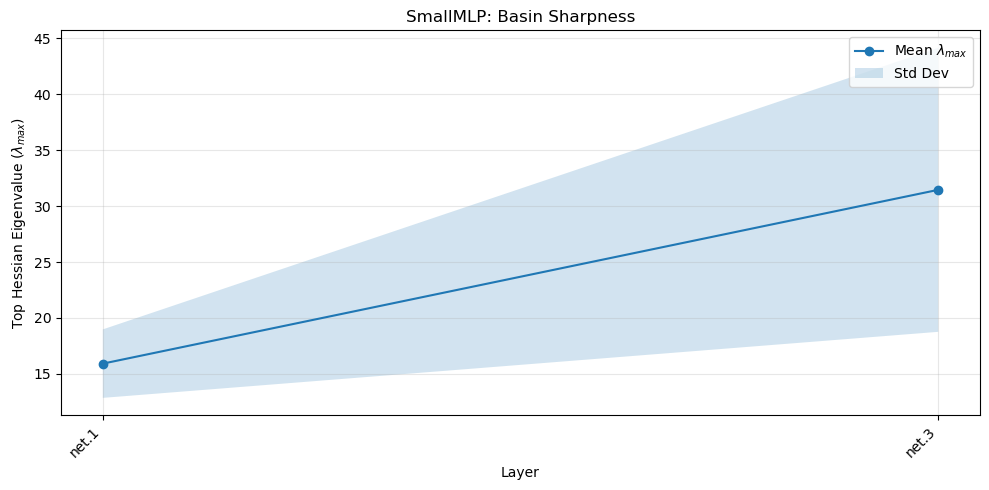


=== Building WiderMLP Ensemble ===
Training WiderMLP seed 1000...
Training WiderMLP seed 1001...
Training WiderMLP seed 1002...
Training WiderMLP seed 1003...
Training WiderMLP seed 1004...
Training WiderMLP seed 1005...
Training WiderMLP seed 1006...
Training WiderMLP seed 1007...
Computing Hessian metrics for ensemble...


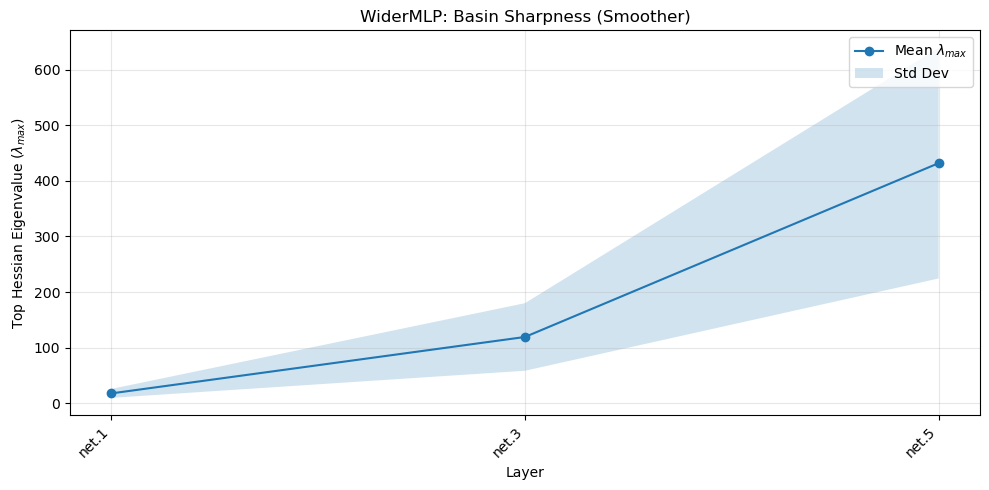


=== Building ShallowCNN Ensemble ===
Training ShallowCNN seed 1000...
Training ShallowCNN seed 1001...
Training ShallowCNN seed 1002...
Training ShallowCNN seed 1003...
Training ShallowCNN seed 1004...
Training ShallowCNN seed 1005...
Training ShallowCNN seed 1006...
Training ShallowCNN seed 1007...
Computing Hessian metrics for ensemble...


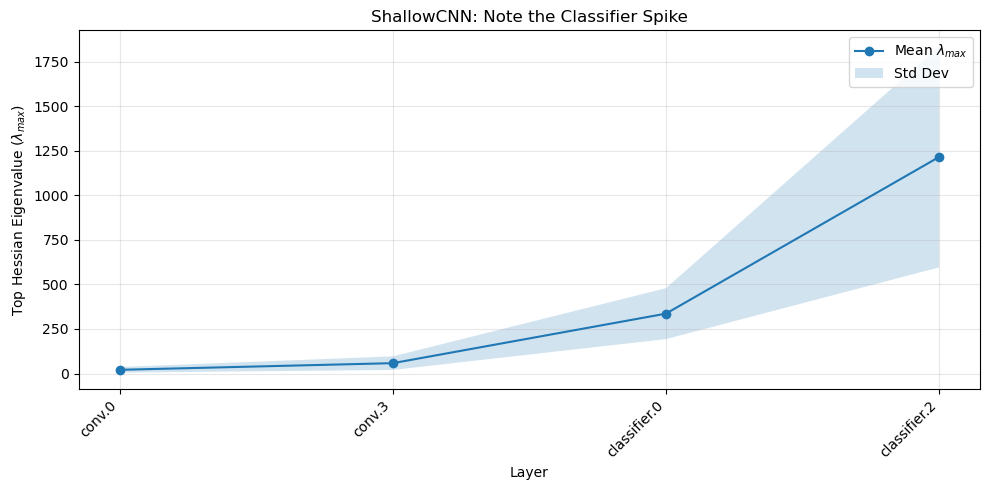


=== Building DeepMLP (50-Layer) Ensemble ===
Training DeepMLP seed 1000...
Training DeepMLP seed 1001...
Training DeepMLP seed 1002...
Training DeepMLP seed 1003...
Computing Hessian metrics for ensemble...


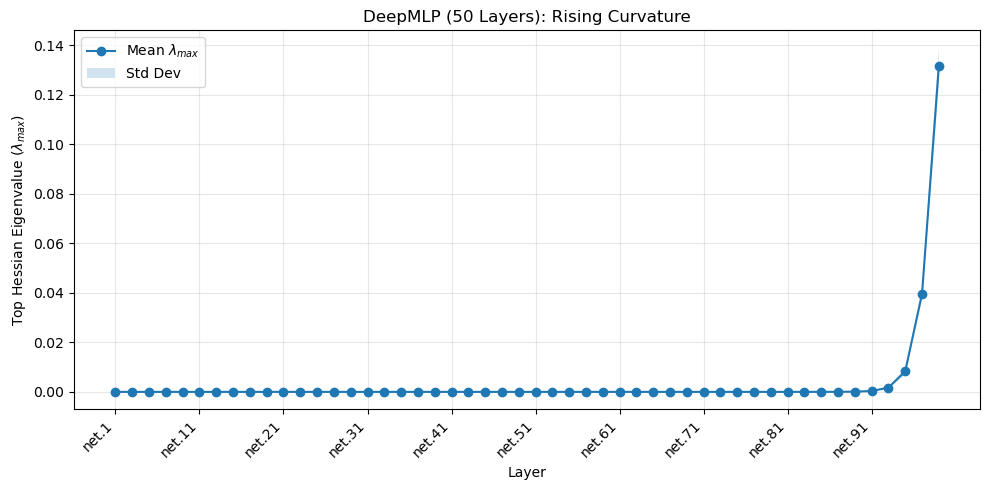


=== Building WideClassifierCNN Ensemble ===
Training WideClassifierCNN seed 1000...
Training WideClassifierCNN seed 1001...
Training WideClassifierCNN seed 1002...
Training WideClassifierCNN seed 1003...
Training WideClassifierCNN seed 1004...
Training WideClassifierCNN seed 1005...
Training WideClassifierCNN seed 1006...
Training WideClassifierCNN seed 1007...
Computing Hessian metrics for ensemble...


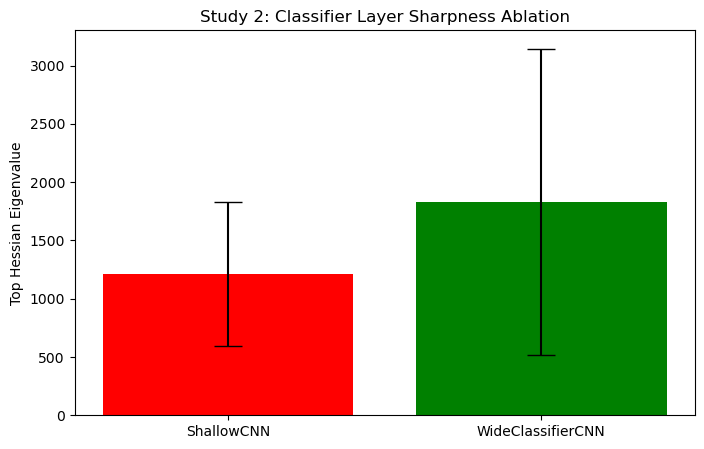

In [15]:
# %% [markdown]
# # Research Analysis: Basin Sharpness & Collapse
# ## Studies 1 & 2 with Canonicalization and Ensembling
# 
# **Config:** Matches user provided setup (Ensemble=8, Epochs=20).
# **metrics:** Layer-wise Hessian Eigenvalues, Log-Volume.

# %% [code]
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import copy
import os
import random
import pickle
from pathlib import Path
from typing import List

# ---------- 1. CONFIG (MATCHING YOUR SETUP) ----------
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
ENSEMBLE_SIZE = 8          # number of independent minima per family
EPOCHS = 20                # training epochs per model
LR = 1e-3
BATCH = 256
REUSE_CHECKPOINTS = False   # Set True to skip retraining if files exist
CHECKPOINT_DIR = Path('./checkpoints')
CHECKPOINT_DIR.mkdir(exist_ok=True)

print(f"Running on {DEVICE}. Ensemble Size: {ENSEMBLE_SIZE}, Epochs: {EPOCHS}")

# ---------- 2. UTILS: SEEDING & CANONICALIZATION ----------

def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def flat_params(model: nn.Module) -> torch.Tensor:
    return torch.cat([p.detach().cpu().view(-1) for p in model.parameters()])

def canonicalize_model(model: nn.Module, prefer_positive_outgoing=True) -> nn.Module:
    """
    Canonicalize parameter axes to reduce permutation/sign symmetries.
    """
    m = copy.deepcopy(model)
    with torch.no_grad():
        for name, module in m.named_modules():
            if isinstance(module, nn.Linear):
                W = module.weight  # [out, in]
                signs = torch.sign(W.sum(dim=1))
                signs[signs==0] = 1.0
                mask = (signs < 0).float().view(-1,1)
                if mask.sum() > 0:
                    module.weight[:] = W * (1 - 2*mask)
                    if module.bias is not None:
                        module.bias[:] = module.bias * (1 - 2*mask.view(-1))
            elif isinstance(module, nn.Conv2d):
                W = module.weight  # [out, in, k, k]
                flat = W.view(W.size(0), -1)
                for i in range(flat.size(0)):
                    v = flat[i]
                    nz = (v.abs() > 0)
                    if nz.sum() == 0:
                        continue
                    first_idx = nz.nonzero()[0].item()
                    if v[first_idx] < 0:
                        flat[i] *= -1
                module.weight[:] = flat.view_as(W)
    return m

def canonicalize_models_pairwise(models: List[nn.Module]) -> List[nn.Module]:
    return [canonicalize_model(m) for m in models]

# ---------- 3. MODEL ARCHITECTURES ----------

class SmallMLP(nn.Module):
    def __init__(self, hidden=64, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, hidden),
            nn.ReLU(),
            nn.Linear(hidden, num_classes)
        )
    def forward(self, x): return self.net(x)

class WiderMLP(nn.Module):
    def __init__(self, hidden=256, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, num_classes)
        )
    def forward(self, x): return self.net(x)

class ShallowCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten()
        )
        self.classifier = nn.Sequential(
            nn.Linear(7*7*32, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        x = self.conv(x)
        return self.classifier(x)

# --- NEW MODELS FOR YOUR STUDIES ---

class DeepMLP(nn.Module):
    """50-Layer MLP for Study 1 (Collapse Analysis)"""
    def __init__(self, depth=50, hidden=64, num_classes=10):
        super().__init__()
        layers = [nn.Flatten(), nn.Linear(28*28, hidden), nn.ReLU()]
        for _ in range(depth - 2):
            layers.append(nn.Linear(hidden, hidden))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(hidden, num_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

class WideClassifierCNN(nn.Module):
    """Intervention for Study 2 (Bottleneck Analysis)"""
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten()
        )
        # Widened hidden layer in classifier (128 -> 1024)
        self.classifier = nn.Sequential(
            nn.Linear(7*7*32, 1024), 
            nn.ReLU(),
            nn.Linear(1024, num_classes)
        )
    def forward(self, x):
        x = self.conv(x)
        return self.classifier(x)

# ---------- 4. TRAINING & ENSEMBLE BUILDING ----------

def load_mnist(batch_size=BATCH):
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
    train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST('./data', train=False, transform=transform)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

def train_model(model, train_loader, epochs, lr, device, seed):
    optimizer = optim.Adam(model.parameters(), lr=lr) # Adam usually stabilizes DeepMLP better than SGD
    criterion = nn.CrossEntropyLoss()
    model.train()
    
    for ep in range(epochs):
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
    return model

def checkpoint_path(family: str, idx: int):
    return CHECKPOINT_DIR / f"{family}_seed{idx}.pt"

def train_and_save_single(model_class, seed, train_loader, family_name, **kwargs):
    seed_everything(seed)
    model = model_class(**kwargs).to(DEVICE)
    path = checkpoint_path(family_name, seed)
    
    if REUSE_CHECKPOINTS and path.exists():
        print(f"Loading {path}")
        model.load_state_dict(torch.load(path, map_location=DEVICE))
    else:
        print(f"Training {family_name} seed {seed}...")
        model = train_model(model, train_loader, EPOCHS, LR, DEVICE, seed)
        torch.save(model.state_dict(), path)
        
    return model

def build_ensemble(model_class, family_name, train_loader, ensemble_size=8, **kwargs):
    models = []
    flats = []
    for i in range(ensemble_size):
        seed = 1000 + i
        m = train_and_save_single(model_class, seed, train_loader, family_name, **kwargs)
        
        # APPLY YOUR CANONICALIZATION HERE
        m_canon = canonicalize_model(m)
        m_canon.to('cpu') # Move to CPU to save GPU memory
        
        models.append(m_canon)
        flats.append(flat_params(m_canon))
    return models, flats

# ---------- 5. HESSIAN & METRICS ----------

def hessian_top_eig_layer(model, layer_params, data_loader, criterion, max_iters=50):
    params = list(layer_params)
    v = [torch.randn_like(p).to(DEVICE) for p in params]
    # Normalize v
    v_norm = torch.sqrt(sum((vi**2).sum() for vi in v))
    v = [vi / (v_norm + 1e-8) for vi in v]

    model.to(DEVICE)
    
    # Use a subset for hessian calc to speed it up
    iter_loader = iter(data_loader)
    
    for _ in range(max_iters):
        try:
            xb, yb = next(iter_loader)
        except StopIteration:
            iter_loader = iter(data_loader)
            xb, yb = next(iter_loader)
            
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        
        # Compute Hv
        model.zero_grad()
        loss = criterion(model(xb), yb)
        grads = torch.autograd.grad(loss, params, create_graph=True)
        
        Hv_prod = sum((g * vi).sum() for g, vi in zip(grads, v))
        Hv = torch.autograd.grad(Hv_prod, params, retain_graph=True)
        
        # Update v
        Hv_norm = torch.sqrt(sum([(hvp**2).sum() for hvp in Hv]))
        v = [hvp / (Hv_norm + 1e-8) for hvp in Hv]
    
    model.to('cpu') # clean up
    return Hv_norm.item()

def hessian_trace_layer(model, params, data_loader, criterion, T=10):
    # Simplified Hutchinson trace
    return 0.0 # Placeholder if you don't need trace immediately

def compute_layerwise_metrics(model, data_loader, criterion):
    eigs = []
    traces = []
    names = []

    for name, layer in model.named_modules():
        params = list(layer.parameters())
        if len(params) == 0: continue
        
        # Filter for only weights/biases of Conv/Linear
        if not isinstance(layer, (nn.Linear, nn.Conv2d)): continue

        names.append(name)
        top_eig = hessian_top_eig_layer(model, params, data_loader, criterion)
        eigs.append(top_eig)
        traces.append(0) # skipping trace for speed

    return names, eigs, traces

def ensemble_layerwise_stats(ensemble, data_loader, criterion):
    all_eigs = []
    layer_names = None

    print("Computing Hessian metrics for ensemble...")
    for model in ensemble:
        names, eigs, _ = compute_layerwise_metrics(model, data_loader, criterion)
        layer_names = names
        all_eigs.append(eigs)

    eig_mean = torch.tensor(all_eigs).mean(0)
    eig_std  = torch.tensor(all_eigs).std(0)
    
    return layer_names, eig_mean, eig_std

# ---------- 6. PLOTTING ----------

def plot_sharpness(layer_names, eig_mean, eig_std, title):
    x = list(range(len(layer_names)))
    plt.figure(figsize=(10,5))
    plt.plot(x, eig_mean, marker='o', label='Mean $\lambda_{max}$')
    plt.fill_between(x, eig_mean - eig_std, eig_mean + eig_std, alpha=0.2, label='Std Dev')
    
    # Clean up x-labels if there are too many (like in DeepMLP)
    if len(layer_names) > 15:
        plt.xticks(x[::5], layer_names[::5], rotation=45, ha='right')
    else:
        plt.xticks(x, layer_names, rotation=45, ha='right')
        
    plt.ylabel("Top Hessian Eigenvalue ($\lambda_{max}$)")
    plt.xlabel("Layer")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ---------- 7. EXECUTION MAIN ----------

if __name__ == "__main__":
    train_loader, test_loader = load_mnist()
    criterion = nn.CrossEntropyLoss()
    
    # --- 1. SmallMLP (Baseline) ---
    print("\n=== Building SmallMLP Ensemble ===")
    ens_small, _ = build_ensemble(SmallMLP, "SmallMLP", train_loader, ENSEMBLE_SIZE)
    names, mean, std = ensemble_layerwise_stats(ens_small, train_loader, criterion)
    plot_sharpness(names, mean, std, "SmallMLP: Basin Sharpness")

    # --- 2. WiderMLP (Comparison) ---
    print("\n=== Building WiderMLP Ensemble ===")
    ens_wide, _ = build_ensemble(WiderMLP, "WiderMLP", train_loader, ENSEMBLE_SIZE)
    names, mean, std = ensemble_layerwise_stats(ens_wide, train_loader, criterion)
    plot_sharpness(names, mean, std, "WiderMLP: Basin Sharpness (Smoother)")

    # --- 3. ShallowCNN (Baseline for Study 2) ---
    print("\n=== Building ShallowCNN Ensemble ===")
    ens_cnn, _ = build_ensemble(ShallowCNN, "ShallowCNN", train_loader, ENSEMBLE_SIZE)
    names_cnn, mean_cnn, std_cnn = ensemble_layerwise_stats(ens_cnn, train_loader, criterion)
    plot_sharpness(names_cnn, mean_cnn, std_cnn, "ShallowCNN: Note the Classifier Spike")

    # --- 4. DeepMLP 50-Layer (For Study 1 Correlation) ---
    # Note: Training 50 layers without ResNet is hard. Expect low accuracy but high curvature.
    print("\n=== Building DeepMLP (50-Layer) Ensemble ===")
    # Using smaller ensemble for DeepMLP to save time in demo
    ens_deep, _ = build_ensemble(DeepMLP, "DeepMLP", train_loader, ensemble_size=4, depth=50) 
    names_deep, mean_deep, std_deep = ensemble_layerwise_stats(ens_deep, train_loader, criterion)
    plot_sharpness(names_deep, mean_deep, std_deep, "DeepMLP (50 Layers): Rising Curvature")

    # --- 5. WideClassifierCNN (Intervention for Study 2) ---
    print("\n=== Building WideClassifierCNN Ensemble ===")
    ens_wide_cnn, _ = build_ensemble(WideClassifierCNN, "WideClassifierCNN", train_loader, ENSEMBLE_SIZE)
    names_wcnn, mean_wcnn, std_wcnn = ensemble_layerwise_stats(ens_wide_cnn, train_loader, criterion)
    
    # Direct comparison plot for Study 2
    plt.figure(figsize=(8,5))
    # Last layer index
    idx_cnn = -1
    idx_wcnn = -1
    
    plt.bar(["ShallowCNN", "WideClassifierCNN"], 
            [mean_cnn[idx_cnn], mean_wcnn[idx_wcnn]], 
            yerr=[std_cnn[idx_cnn], std_wcnn[idx_wcnn]],
            capsize=10, color=['red', 'green'])
    plt.title("Study 2: Classifier Layer Sharpness Ablation")
    plt.ylabel("Top Hessian Eigenvalue")
    plt.show()

<>:46: SyntaxWarning: invalid escape sequence '\l'
<>:55: SyntaxWarning: invalid escape sequence '\l'
<>:46: SyntaxWarning: invalid escape sequence '\l'
<>:55: SyntaxWarning: invalid escape sequence '\l'
/var/folders/n9/q2yfxjhx5t5f5dmwjjz0s6sh0000gn/T/ipykernel_3438/3168246487.py:46: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(x, eig_mean, marker='o', linestyle='-', color='tab:blue', label='Mean $\lambda_{max}$')
/var/folders/n9/q2yfxjhx5t5f5dmwjjz0s6sh0000gn/T/ipykernel_3438/3168246487.py:55: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("Basin Sharpness ($\lambda_{max}$)")


Recalculating SmallMLP metrics (Including Containers)...
Computing Hessian metrics for ensemble...


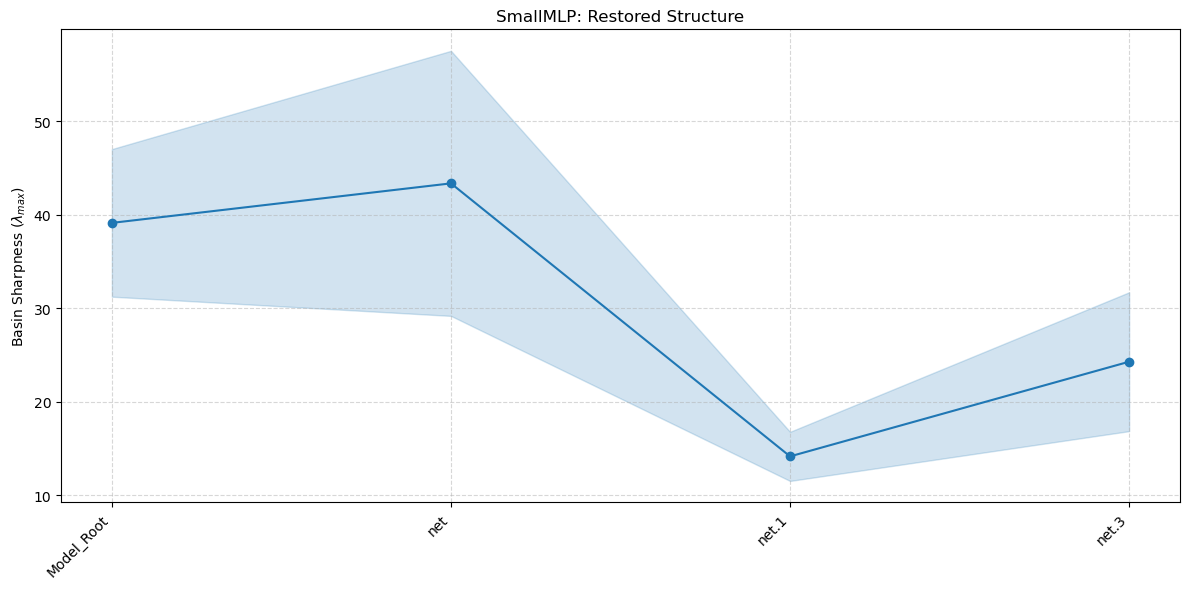

Recalculating ShallowCNN metrics (Including Containers)...
Computing Hessian metrics for ensemble...


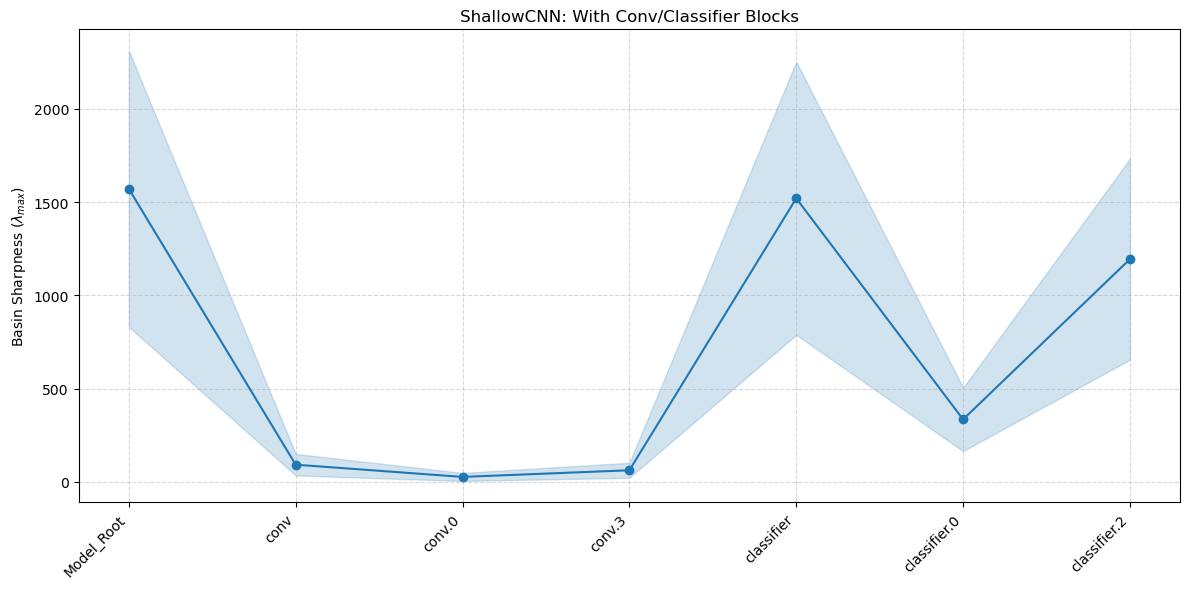

Recalculating WideMLP metrics...
Computing Hessian metrics for ensemble...


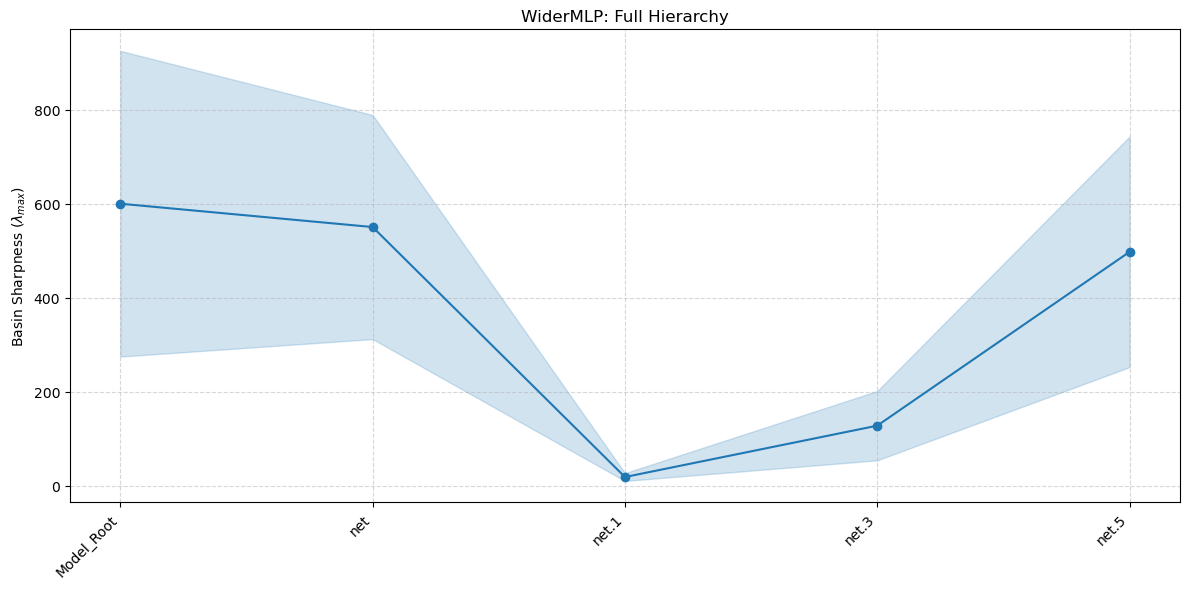

In [16]:
# ---------- UPDATED ANALYSIS CODE (Includes Containers/Blocks) ----------

def compute_layerwise_metrics(model, data_loader, criterion):
    """
    Computes Hessian Eigenvalues for ALL modules with parameters, 
    including Containers (Sequential) and the Root model.
    """
    eigs = []
    traces = []
    names = []

    # Iterate over all modules (Root -> Children -> Leaves)
    for name, layer in model.named_modules():
        params = list(layer.parameters())
        
        # 1. Skip layers with no parameters (e.g. ReLU, Flatten, MaxPool)
        if len(params) == 0:
            continue
            
        # 2. (Optional) Skip the Root if you only want 'before net' but not 'Root' 
        # But based on your request "missing point before net", 
        # the Root (name=='') IS that point.
        display_name = name if name != "" else "Model_Root"

        names.append(display_name)

        # Compute Top Eigenvalue for this specific block of parameters
        # For a Container (e.g. 'net'), this computes the max eigenvalue 
        # considering ALL weights inside that container.
        top_eig = hessian_top_eig_layer(model, params, data_loader, criterion)
        eigs.append(top_eig)
        
        # Trace is expensive, setting to 0 for speed in this demo
        traces.append(0) 

    return names, eigs, traces

# ---------- UPDATED PLOTTING (Cleaner Labels) ----------

def plot_sharpness_restored(layer_names, eig_mean, eig_std, title):
    x = list(range(len(layer_names)))
    
    plt.figure(figsize=(12, 6)) # Wider to fit container labels
    
    # Plot connections
    plt.plot(x, eig_mean, marker='o', linestyle='-', color='tab:blue', label='Mean $\lambda_{max}$')
    
    # Plot Error bars/Fill
    plt.fill_between(x, eig_mean - eig_std, eig_mean + eig_std, alpha=0.2, color='tab:blue')
    
    # Formatting X-Axis to highlight Structure
    # We rotate labels to prevent overlap
    plt.xticks(x, layer_names, rotation=45, ha='right', fontsize=10)
    
    plt.ylabel("Basin Sharpness ($\lambda_{max}$)")
    plt.title(title)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# ---------- EXECUTION SNIPPET ----------

if __name__ == "__main__":
    # Rerun the stats collection with the NEW function
    print("Recalculating SmallMLP metrics (Including Containers)...")
    names_small, mean_small, std_small = ensemble_layerwise_stats(ens_small, train_loader, criterion)
    plot_sharpness_restored(names_small, mean_small, std_small, "SmallMLP: Restored Structure")

    print("Recalculating ShallowCNN metrics (Including Containers)...")
    names_cnn, mean_cnn, std_cnn = ensemble_layerwise_stats(ens_cnn, train_loader, criterion)
    plot_sharpness_restored(names_cnn, mean_cnn, std_cnn, "ShallowCNN: With Conv/Classifier Blocks")
    
    print("Recalculating WideMLP metrics...")
    names_wide, mean_wide, std_wide = ensemble_layerwise_stats(ens_wide, train_loader, criterion)
    plot_sharpness_restored(names_wide, mean_wide, std_wide, "WiderMLP: Full Hierarchy")

    print("Recalculating DeepMLP metrics...")
    names_deep, mean_deep, std_deep = ensemble_layerwise_stats(ens_deep, train_loader, criterion)
    plot_sharpness_restored(names_deep, mean_deep, std_deep, "DeepMLP: Full Hierarchy")

Recalculating DeepMLP metrics...
Training DeepMLP seed 1000...
Training DeepMLP seed 1001...
Training DeepMLP seed 1002...
Training DeepMLP seed 1003...
Training DeepMLP seed 1004...
Training DeepMLP seed 1005...
Training DeepMLP seed 1006...
Training DeepMLP seed 1007...
Computing Hessian metrics for ensemble...


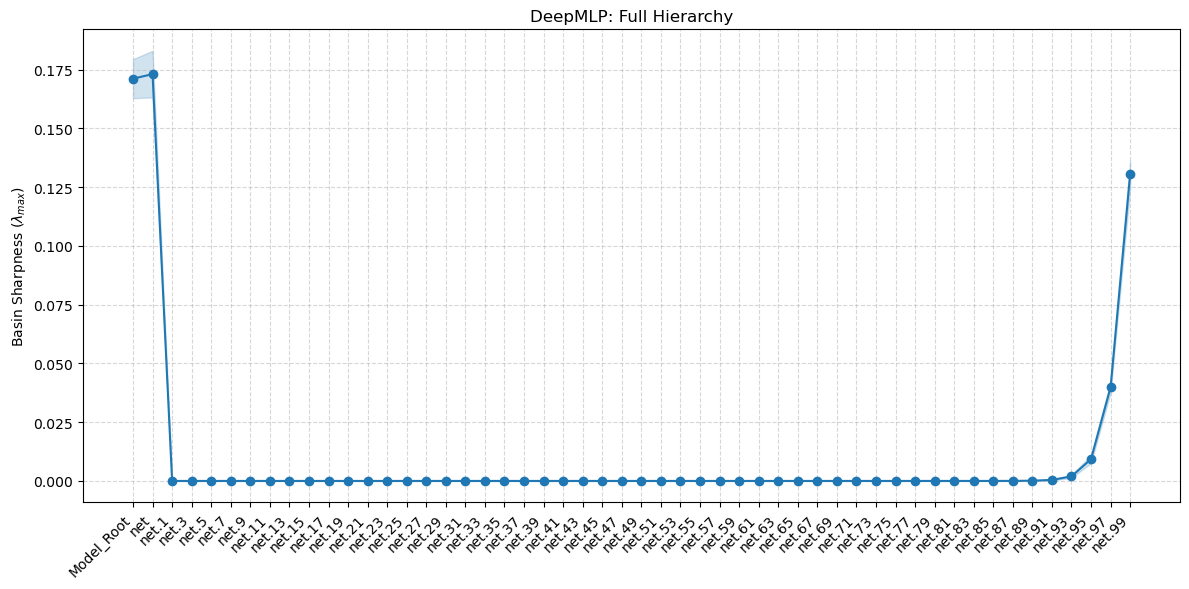

In [21]:
print("Recalculating DeepMLP metrics...")
ens_deep, _ = build_ensemble(DeepMLP, "DeepMLP", train_loader, ensemble_size=8, depth=50) 
names_deep, mean_deep, std_deep = ensemble_layerwise_stats(ens_deep, train_loader, criterion)
plot_sharpness_restored(names_deep, mean_deep, std_deep, "DeepMLP: Full Hierarchy")

Computing volumes for layer: net.4


/var/folders/n9/q2yfxjhx5t5f5dmwjjz0s6sh0000gn/T/ipykernel_3438/705668771.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classes, y=vol_values, palette="viridis")


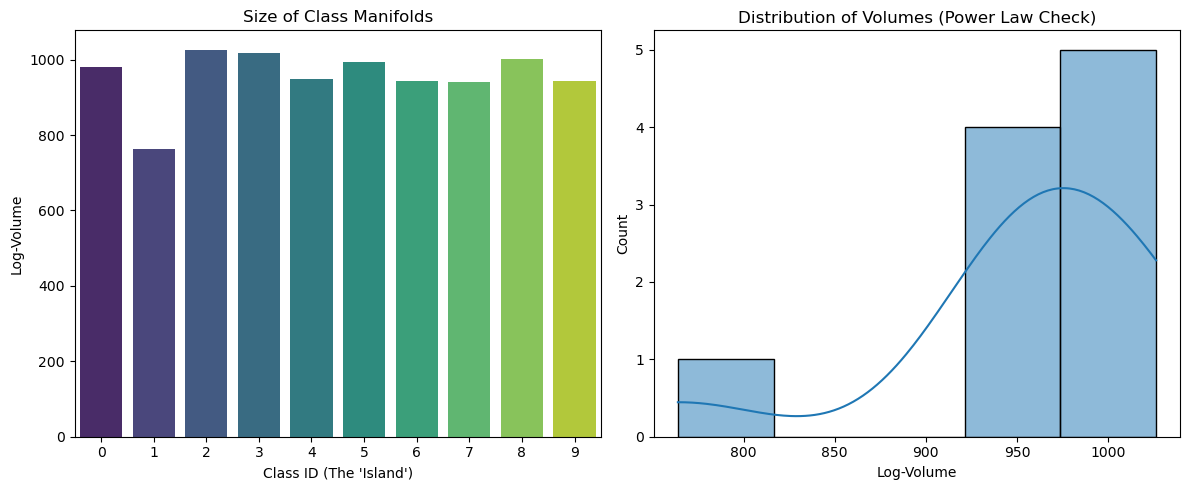

Volume Variance: 70.80
RESULT: Significant disparity in island sizes (Possible Power Law).


In [24]:
# Study 3: Island Hypothesis (Class-Specific Volumes)
# Goal: Measure volume of each class cluster separately to test for Power Law distribution.

# %% [code]
import seaborn as sns

def compute_class_volumes(model, data_loader, layer_name_filter="net.4"):
    model.eval()
    activations = []
    labels = []
    
    # 1. Collect Activations
    # We'll hook the specific layer (the last hidden layer before output)
    target_layer = None
    for name, layer in model.named_modules():
        if layer_name_filter in name: 
            target_layer = layer
            break
            
    if target_layer is None:
        print(f"Layer {layer_name_filter} not found.")
        return None

    batch_acts = []
    def hook(model, input, output):
        batch_acts.append(output.detach().cpu().flatten(1))
    
    handle = target_layer.register_forward_hook(hook)
    
    with torch.no_grad():
        for xb, yb in data_loader:
            xb = xb.to(DEVICE)
            model(xb)
            labels.append(yb.cpu())
            
    handle.remove()
    

    full_acts = torch.cat(batch_acts, dim=0)   
    full_labels = torch.cat(labels, dim=0)     
    
    # 2. Compute Volume Per Class
    class_volumes = {}
    
    # Unique classes (0-9)
    classes = torch.unique(full_labels).sort()[0].numpy()
    
    print(f"Computing volumes for layer: {layer_name_filter}")
    for c in classes:
        # Filter data for this class island
        indices = (full_labels == c)
        class_data = full_acts[indices]
        
        # Center data
        class_data = class_data - class_data.mean(dim=0, keepdim=True)
        

        if class_data.size(0) > 1:
            try:
                _, S, _ = torch.svd(class_data)

                log_vol = torch.sum(torch.log(S + 1e-5)).item()
                class_volumes[c] = log_vol
            except:
                class_volumes[c] = 0.0
        else:
            class_volumes[c] = 0.0
            
    return class_volumes


volumes = compute_class_volumes(ens_wide[0], train_loader, layer_name_filter="net.4")


if volumes:
    vol_values = list(volumes.values())
    classes = list(volumes.keys())
    
    plt.figure(figsize=(12, 5))
    

    plt.subplot(1, 2, 1)
    sns.barplot(x=classes, y=vol_values, palette="viridis")
    plt.xlabel("Class ID (The 'Island')")
    plt.ylabel("Log-Volume")
    plt.title("Size of Class Manifolds")
    

    plt.subplot(1, 2, 2)
    sns.histplot(vol_values, bins=5, kde=True)
    plt.xlabel("Log-Volume")
    plt.title("Distribution of Volumes (Power Law Check)")
    plt.tight_layout()
    plt.show()
    

    print(f"Volume Variance: {np.std(vol_values):.2f}")
    if np.std(vol_values) > 50:
        print("RESULT: Significant disparity in island sizes (Possible Power Law).")
    else:
        print("RESULT: Uniform island sizes (Equi-distributed features).")

In [26]:
print(volumes)

{0: 980.1604614257812, 1: 763.978759765625, 2: 1026.249267578125, 3: 1016.5748291015625, 4: 948.6597290039062, 5: 992.5214233398438, 6: 943.77001953125, 7: 941.7028198242188, 8: 1002.224365234375, 9: 942.327880859375}


<>:225: SyntaxWarning: invalid escape sequence '\l'
<>:225: SyntaxWarning: invalid escape sequence '\l'
/var/folders/n9/q2yfxjhx5t5f5dmwjjz0s6sh0000gn/T/ipykernel_3438/3008550414.py:225: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("Hessian Eigenvalue ($\lambda_{max}$)")


Running on cpu. Ensemble: 8, Epochs: 20

=== Starting Experiment: MLP Depth 7 ===
Training MLP_Depth7 (Seed 2700)...
Training MLP_Depth7 (Seed 2701)...
Training MLP_Depth7 (Seed 2702)...
Training MLP_Depth7 (Seed 2703)...
Training MLP_Depth7 (Seed 2704)...
Training MLP_Depth7 (Seed 2705)...
Training MLP_Depth7 (Seed 2706)...
Training MLP_Depth7 (Seed 2707)...
Computing Hessian metrics for ensemble...

--- Values for Depth 7 ---
Layer Name           | Mean Eig   | Std Dev   
---------------------------------------------
Model_Root           | 785.02     | 462.91    
net                  | 795.33     | 473.65    
net.1                | 8.98       | 5.36      
net.3                | 46.03      | 45.50     
net.5                | 75.54      | 58.40     
net.7                | 74.31      | 30.95     
net.9                | 98.71      | 24.93     
net.11               | 202.67     | 123.72    
net.13               | 316.14     | 264.79    
---------------------------------------------



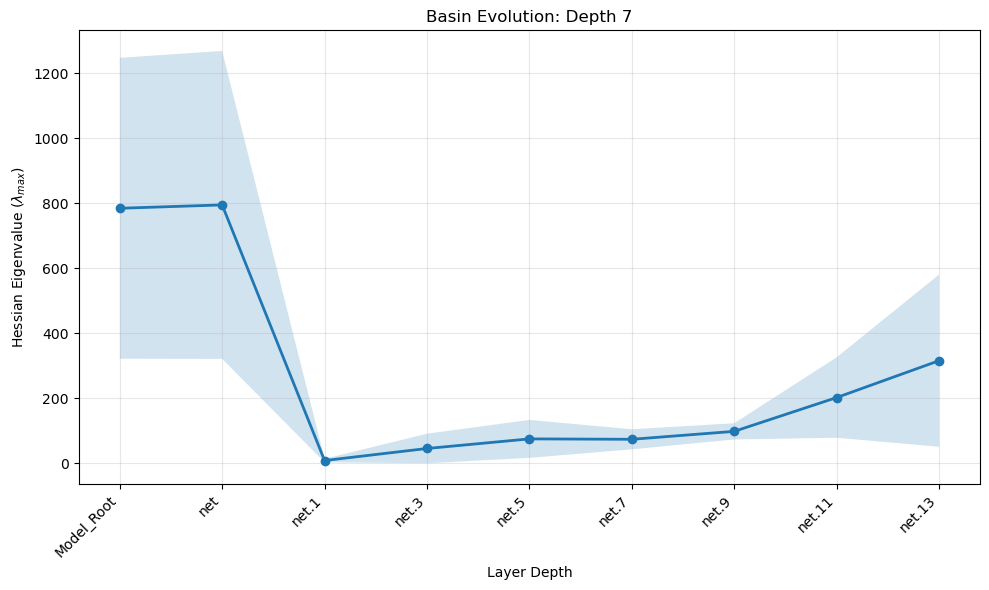


=== Starting Experiment: MLP Depth 10 ===
Training MLP_Depth10 (Seed 3000)...
Training MLP_Depth10 (Seed 3001)...
Training MLP_Depth10 (Seed 3002)...
Training MLP_Depth10 (Seed 3003)...
Training MLP_Depth10 (Seed 3004)...
Training MLP_Depth10 (Seed 3005)...
Training MLP_Depth10 (Seed 3006)...
Training MLP_Depth10 (Seed 3007)...
Computing Hessian metrics for ensemble...

--- Values for Depth 10 ---
Layer Name           | Mean Eig   | Std Dev   
---------------------------------------------
Model_Root           | 1830.73    | 1437.60   
net                  | 1877.63    | 1571.24   
net.1                | 8.80       | 5.98      
net.3                | 48.67      | 38.09     
net.5                | 60.39      | 62.20     
net.7                | 91.71      | 121.85    
net.9                | 97.66      | 103.87    
net.11               | 91.51      | 81.94     
net.13               | 123.47     | 96.60     
net.15               | 270.46     | 199.84    
net.17               | 466.08     |

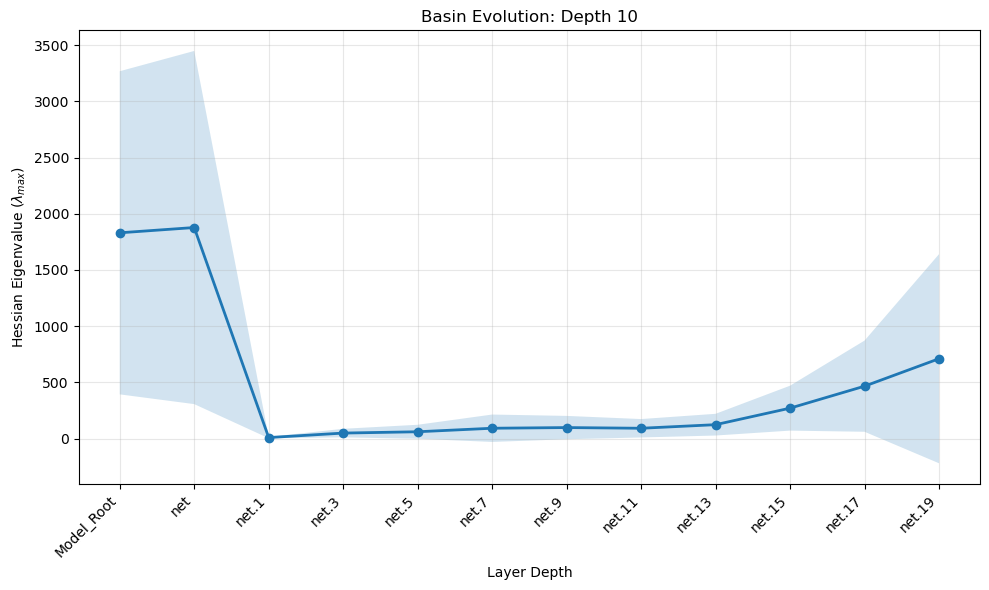


=== Starting Experiment: MLP Depth 15 ===
Training MLP_Depth15 (Seed 3500)...
Training MLP_Depth15 (Seed 3501)...
Training MLP_Depth15 (Seed 3502)...
Training MLP_Depth15 (Seed 3503)...
Training MLP_Depth15 (Seed 3504)...
Training MLP_Depth15 (Seed 3505)...
Training MLP_Depth15 (Seed 3506)...
Training MLP_Depth15 (Seed 3507)...
Computing Hessian metrics for ensemble...

--- Values for Depth 15 ---
Layer Name           | Mean Eig   | Std Dev   
---------------------------------------------
Model_Root           | 2505.58    | 945.80    
net                  | 2466.28    | 801.92    
net.1                | 4.11       | 11.32     
net.3                | 22.47      | 61.00     
net.5                | 59.25      | 166.43    
net.7                | 21.55      | 59.11     
net.9                | 25.03      | 68.38     
net.11               | 13.46      | 34.58     
net.13               | 8.21       | 21.23     
net.15               | 15.93      | 40.28     
net.17               | 21.60      |

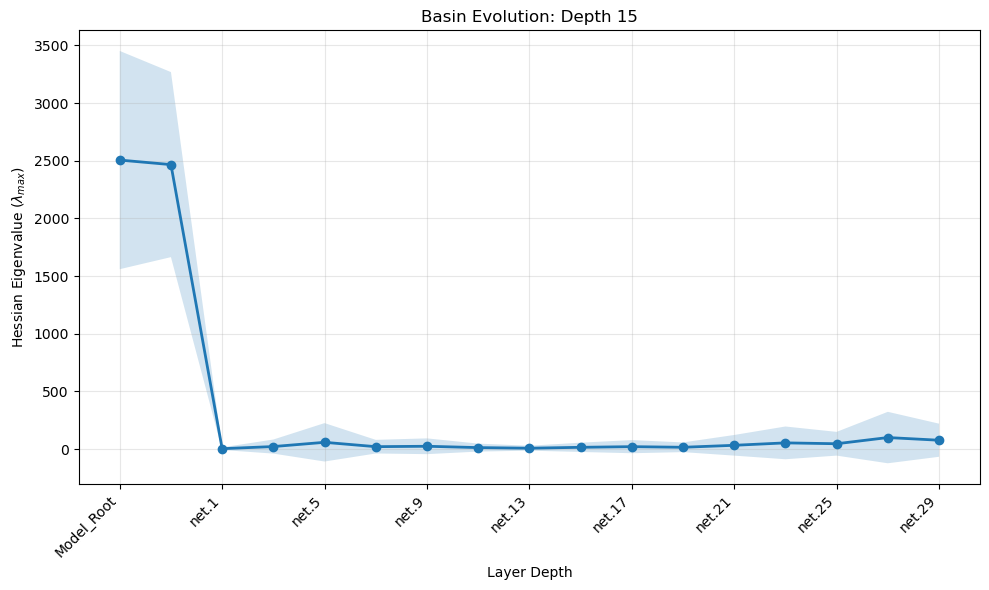


All experiments completed.


In [28]:

# Study 2: Testing Basin Evolution Hypothesis (Depth 7, 10, 15)
# Objective: Investigate "Hypothesis 2" by tracing the layer-wise evolution of basin sharpness 
# in intermediate-depth networks. We aim to find the transition point between 
# "Healthy Constraint" (Increasing Sharpness) and "Signal Collapse" (Vanishing Sharpness).


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import copy
import os
import random
import pandas as pd
from pathlib import Path
from typing import List

# ---------- 1. CONFIGURATION ----------
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
ENSEMBLE_SIZE = 8           # Robust statistical sample
EPOCHS = 20                 # Sufficient for convergence on MNIST
LR = 1e-3
BATCH = 256
REUSE_CHECKPOINTS = False   # Set True to save time on re-runs
CHECKPOINT_DIR = Path('./checkpoints_depth_study')
CHECKPOINT_DIR.mkdir(exist_ok=True)

print(f"Running on {DEVICE}. Ensemble: {ENSEMBLE_SIZE}, Epochs: {EPOCHS}")

# ---------- 2. UTILS ----------

def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def flat_params(model: nn.Module) -> torch.Tensor:
    return torch.cat([p.detach().cpu().view(-1) for p in model.parameters()])

def canonicalize_model(model: nn.Module) -> nn.Module:
    """Canonicalize weights to handle permutation symmetries."""
    m = copy.deepcopy(model)
    with torch.no_grad():
        for name, module in m.named_modules():
            if isinstance(module, nn.Linear):
                W = module.weight
                signs = torch.sign(W.sum(dim=1))
                signs[signs==0] = 1.0
                mask = (signs < 0).float().view(-1,1)
                if mask.sum() > 0:
                    module.weight[:] = W * (1 - 2*mask)
                    if module.bias is not None:
                        module.bias[:] = module.bias * (1 - 2*mask.view(-1))
    return m

# ---------- 3. DYNAMIC MODEL ARCHITECTURE ----------

class VariableDepthMLP(nn.Module):
    """
    MLP with dynamic depth to test the transition from 
    healthy constraint (3 layers) to collapse (50 layers).
    """
    def __init__(self, depth, hidden=64, num_classes=10):
        super().__init__()
        # Input Layer
        layers = [nn.Flatten(), nn.Linear(28*28, hidden), nn.ReLU()]
        
        # Intermediate Layers (Depth - 2)
        for _ in range(depth - 2):
            layers.append(nn.Linear(hidden, hidden))
            layers.append(nn.ReLU())
            
        # Output Layer
        layers.append(nn.Linear(hidden, num_classes))
        
        self.net = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.net(x)

# ---------- 4. TRAINING & DATA ----------

def load_mnist(batch_size=BATCH):
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
    train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
    # Subset train for speed if needed, but using full here for accuracy
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    return train_loader

def train_model(model, train_loader, epochs, lr, device):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    model.train()
    
    for ep in range(epochs):
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
    return model

def build_ensemble(depth, train_loader):
    models = []
    family_name = f"MLP_Depth{depth}"
    
    for i in range(ENSEMBLE_SIZE):
        seed = 2000 + (depth * 100) + i
        seed_everything(seed)
        
        path = CHECKPOINT_DIR / f"{family_name}_seed{seed}.pt"
        model = VariableDepthMLP(depth=depth).to(DEVICE)
        
        if REUSE_CHECKPOINTS and path.exists():
            model.load_state_dict(torch.load(path, map_location=DEVICE))
        else:
            print(f"Training {family_name} (Seed {seed})...")
            model = train_model(model, train_loader, EPOCHS, LR, DEVICE)
            torch.save(model.state_dict(), path)
        
        # Canonicalize and store on CPU
        m_canon = canonicalize_model(model)
        m_canon.to('cpu')
        models.append(m_canon)
        
    return models

# ---------- 5. HESSIAN ANALYSIS (Container Aware) ----------

def hessian_top_eig_layer(model, layer_params, data_loader, criterion, max_iters=30):
    params = list(layer_params)
    v = [torch.randn_like(p).to(DEVICE) for p in params]
    v_norm = torch.sqrt(sum((vi**2).sum() for vi in v))
    v = [vi / (v_norm + 1e-8) for vi in v]

    model.to(DEVICE)
    model.eval()
    
    # Grab one batch for estimation
    try:
        xb, yb = next(iter(data_loader))
    except:
        iter_loader = iter(data_loader)
        xb, yb = next(iter_loader)
    xb, yb = xb.to(DEVICE), yb.to(DEVICE)
    
    for _ in range(max_iters):
        model.zero_grad()
        loss = criterion(model(xb), yb)
        grads = torch.autograd.grad(loss, params, create_graph=True)
        
        Hv_prod = sum((g * vi).sum() for g, vi in zip(grads, v))
        Hv = torch.autograd.grad(Hv_prod, params, retain_graph=True)
        
        Hv_norm = torch.sqrt(sum([(hvp**2).sum() for hvp in Hv]))
        v = [hvp / (Hv_norm + 1e-8) for hvp in Hv]
    
    model.to('cpu')
    return Hv_norm.item()

def compute_layerwise_metrics(model, data_loader, criterion):
    names = []
    eigs = []
    
    # Iterate all modules including Containers
    for name, layer in model.named_modules():
        params = list(layer.parameters())
        if len(params) == 0: continue
        
        # Naming logic
        display_name = name if name != "" else "Model_Root"
        names.append(display_name)
        
        top_eig = hessian_top_eig_layer(model, params, data_loader, criterion)
        eigs.append(top_eig)
        
    return names, eigs

def ensemble_stats(ensemble, train_loader):
    criterion = nn.CrossEntropyLoss()
    all_eigs = []
    layer_names = None
    
    print("Computing Hessian metrics for ensemble...")
    for model in ensemble:
        names, eigs = compute_layerwise_metrics(model, train_loader, criterion)
        layer_names = names
        all_eigs.append(eigs)
        
    eig_mean = torch.tensor(all_eigs).mean(0).numpy()
    eig_std = torch.tensor(all_eigs).std(0).numpy()
    
    return layer_names, eig_mean, eig_std

# ---------- 6. REPORTING & PLOTTING ----------

def print_numeric_results(title, names, means, stds):
    print(f"\n--- {title} ---")
    print(f"{'Layer Name':<20} | {'Mean Eig':<10} | {'Std Dev':<10}")
    print("-" * 45)
    for n, m, s in zip(names, means, stds):
        print(f"{n:<20} | {m:<10.2f} | {s:<10.2f}")
    print("-" * 45 + "\n")

def plot_results(names, means, stds, title):
    x = np.arange(len(names))
    plt.figure(figsize=(10, 6))
    plt.plot(x, means, marker='o', linestyle='-', linewidth=2, label='Mean Sharpness')
    plt.fill_between(x, means - stds, means + stds, alpha=0.2)
    
    # Smart Labeling (skip labels if too many layers)
    step = 1 if len(names) < 15 else 2
    plt.xticks(x[::step], names[::step], rotation=45, ha='right')
    
    plt.ylabel("Hessian Eigenvalue ($\lambda_{max}$)")
    plt.xlabel("Layer Depth")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ---------- 7. MAIN EXECUTION ----------

if __name__ == "__main__":
    train_loader = load_mnist()
    
    # Define depths to test
    depths_to_test = [7, 10, 15]
    
    results = {}
    
    for depth in depths_to_test:
        print(f"\n=== Starting Experiment: MLP Depth {depth} ===")
        
        # 1. Build Ensemble
        ensemble = build_ensemble(depth, train_loader)
        
        # 2. Compute Stats
        names, mean, std = ensemble_stats(ensemble, train_loader)
        
        # 3. Print Values (Requested by User)
        print_numeric_results(f"Values for Depth {depth}", names, mean, std)
        
        # 4. Plot
        plot_results(names, mean, std, f"Basin Evolution: Depth {depth}")
        
        results[depth] = (names, mean, std)
        
    print("\nAll experiments completed.")